In [515]:
import pandas as pd
import numpy as np
import skfuzzy as fuzz
from collections import defaultdict
import matplotlib.pyplot as plt

In [516]:
df = pd.read_csv("./datasets/mackey_glass.csv")
print(f"Data loaded. Total length: {len(df)}")

split_ratio = 0.8
split_idx = int(split_ratio * len(df))

train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

train_values = train_df["value"].values  
test_values  = test_df['value'].values

print(f"Train: {len(train_df)} samples  ({split_ratio*100:.0f}%)")
print(f"Test: {len(test_df)} samples   ({(1-split_ratio)*100:.0f}%)")

Data loaded. Total length: 1000
Train: 800 samples  (80%)
Test: 200 samples   (20%)


In [517]:
y_min = train_df["value"].min()
y_max = train_df["value"].max()
D = 0.2 * (y_max - y_min)
U_min = y_min - D
U_max = y_max + D

print(f"U_min: {U_min:.4f}    U_max: {U_max:.4f}")

U_min: -0.2609    U_max: 1.8168


In [518]:
series_train = train_df["value"].values
n = len(series_train)
tau = 17
m = 3

N = n - (m - 1) * tau
X = np.zeros((N, m))
for i in range(m):
    X[:, i] = series_train[i*tau : i*tau + N]

print(f"Phase space shape (train): {X.shape}")

Phase space shape (train): (766, 3)


c= 2 → PC = 0.3351
c= 3 → PC = 0.1994
c= 4 → PC = 0.1395
c= 5 → PC = 0.1031
c= 6 → PC = 0.0821
c= 7 → PC = 0.0682
c= 8 → PC = 0.0601
c= 9 → PC = 0.0514
c=10 → PC = 0.0445
c=11 → PC = 0.0394


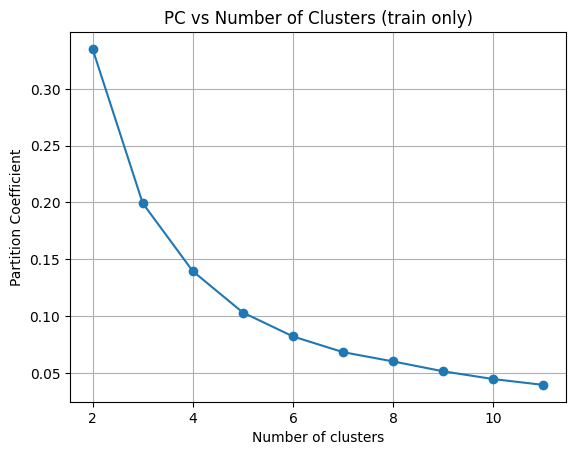

In [519]:
pcs = []
for c in range(2, 12):
    cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
        X.T, c=c, m=2.0, error=0.005, maxiter=1000
    )
    pc = np.mean(u**2)
    pcs.append(pc)
    print(f"c={c:2d} → PC = {pc:.4f}")

plt.plot(range(2, 12), pcs, 'o-')
plt.xlabel("Number of clusters")
plt.ylabel("Partition Coefficient")
plt.title("PC vs Number of Clusters (train only)")
plt.grid(True)
plt.show()

In [586]:
c_selected = 27
print(f"\nSelected number of clusters: {c_selected}")

cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    X.T, c=c_selected, m=2.0, error=0.005, maxiter=1000
)

centers = np.sort(cntr[:, 0])
print("Sorted centers:", centers)


Selected number of clusters: 27
Sorted centers: [0.0995078  0.12406139 0.17367748 0.28212376 0.32377375 0.38983396
 0.41154395 0.44795016 0.46296831 0.56270755 0.57045827 0.58555246
 0.58651685 0.7231131  0.75701055 0.76121182 0.87703516 0.91797514
 0.93206615 1.03842433 1.09606585 1.1665724  1.17494731 1.29596134
 1.36598833 1.37725426 1.41478334]


In [587]:
boundaries = [(centers[i] + centers[i+1])/2 for i in range(len(centers)-1)]



intervals = [(U_min, boundaries[0])]
for i in range(len(boundaries)-1):
    intervals.append((boundaries[i], boundaries[i+1]))
intervals.append((boundaries[-1], U_max))

fuzzy_sets = []
for i in range(len(centers)):
    if i == 0:
        a, b, c = intervals[0][0], centers[0], centers[1]
    elif i == len(centers)-1:
        a, b, c = centers[-2], centers[-1], intervals[-1][1]
    else:
        a, b, c = centers[i-1], centers[i], centers[i+1]
    fuzzy_sets.append((a, b, c))

print("\nFuzzy sets (triangular):")
for i, (a,b,c) in enumerate(fuzzy_sets, 1):
    print(f"A{i}:  {a:>8.4f} → {b:>8.4f} → {c:>8.4f}")


Fuzzy sets (triangular):
A1:   -0.2609 →   0.0995 →   0.1241
A2:    0.0995 →   0.1241 →   0.1737
A3:    0.1241 →   0.1737 →   0.2821
A4:    0.1737 →   0.2821 →   0.3238
A5:    0.2821 →   0.3238 →   0.3898
A6:    0.3238 →   0.3898 →   0.4115
A7:    0.3898 →   0.4115 →   0.4480
A8:    0.4115 →   0.4480 →   0.4630
A9:    0.4480 →   0.4630 →   0.5627
A10:    0.4630 →   0.5627 →   0.5705
A11:    0.5627 →   0.5705 →   0.5856
A12:    0.5705 →   0.5856 →   0.5865
A13:    0.5856 →   0.5865 →   0.7231
A14:    0.5865 →   0.7231 →   0.7570
A15:    0.7231 →   0.7570 →   0.7612
A16:    0.7570 →   0.7612 →   0.8770
A17:    0.7612 →   0.8770 →   0.9180
A18:    0.8770 →   0.9180 →   0.9321
A19:    0.9180 →   0.9321 →   1.0384
A20:    0.9321 →   1.0384 →   1.0961
A21:    1.0384 →   1.0961 →   1.1666
A22:    1.0961 →   1.1666 →   1.1749
A23:    1.1666 →   1.1749 →   1.2960
A24:    1.1749 →   1.2960 →   1.3660
A25:    1.2960 →   1.3660 →   1.3773
A26:    1.3660 →   1.3773 →   1.4148
A27:    1.3773 →   1.

In [588]:
def triangular_mf(x, a, b, c):
    if x <= a or x >= c:
        return 0.0
    if x <= b:
        return (x - a) / (b - a) if b != a else 0.0
    return (c - x) / (c - b) if c != b else 0.0

def fuzzify(value, fuzzy_sets):
    mfs = [triangular_mf(value, *fs) for fs in fuzzy_sets]
    return np.argmax(mfs)

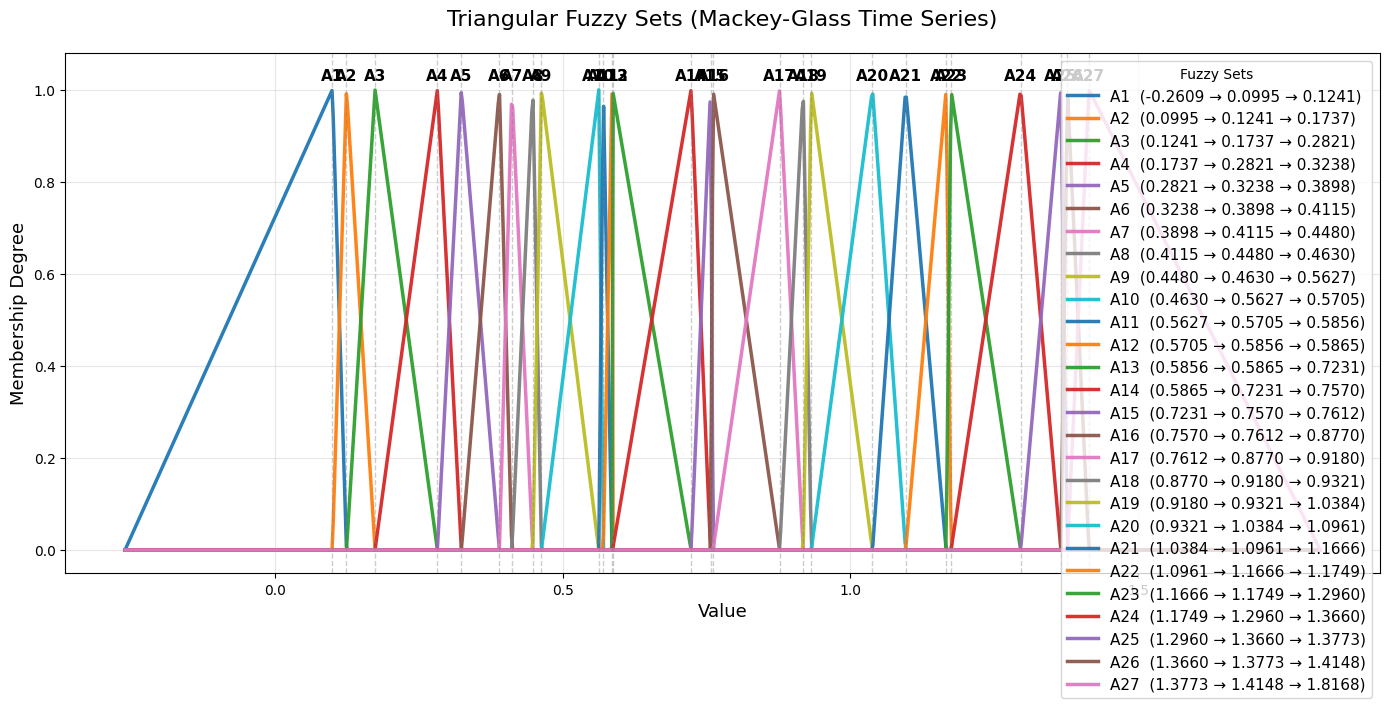

In [589]:
# =============================================================================
# VISUALIZATION OF TRIANGULAR FUZZY SETS
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

# x range over the whole universe of discourse
x = np.linspace(U_min, U_max, 1000)

plt.figure(figsize=(14, 7))

for i, (a, b, c) in enumerate(fuzzy_sets, 1):
    # Compute membership for every point
    y = [triangular_mf(val, a, b, c) for val in x]
    
    plt.plot(x, y, 
             label=f'A{i}  ({a:.4f} → {b:.4f} → {c:.4f})',
             linewidth=2.5,
             alpha=0.95)

# Add vertical lines at the centers (the peaks)
for i, (a, b, c) in enumerate(fuzzy_sets, 1):
    plt.axvline(x=b, color='gray', linestyle='--', alpha=0.4, linewidth=1)
    plt.text(b, 1.02, f'A{i}', ha='center', fontsize=11, fontweight='bold')

plt.title('Triangular Fuzzy Sets (Mackey-Glass Time Series)', fontsize=16, pad=20)
plt.xlabel('Value', fontsize=13)
plt.ylabel('Membership Degree', fontsize=13)
plt.legend(title='Fuzzy Sets', fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3)
plt.ylim(-0.05, 1.08)
plt.tight_layout()
plt.show()

In [590]:
all_values = df["value"].values
labels = np.array([fuzzify(v, fuzzy_sets) for v in all_values])

print("\nUnique labels:", np.unique(labels))
print("First 15 labels:", labels[:15])


Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26]
First 15 labels: [8 7 6 5 4 3 3 3 2 2 2 2 1 1 1]


In [591]:
def which_partition(value, fuzzy_sets):

    memberships = []
    
    for a, b, c in fuzzy_sets:
        if value <= a or value >= c:
            mu = 0.0
        elif value <= b:
            mu = (value - a) / (b - a) if b != a else 0.0
        else:
            mu = (c - value) / (c - b) if c != b else 0.0
        memberships.append(mu)
    
    if max(memberships) == 0:
    
        return None 
    
    return np.argmax(memberships)



In [592]:

train_partitions = []
for val in train_values:
    idx = which_partition(val, fuzzy_sets)
    if idx is None:
        train_partitions.append(-1)  
    else:
        train_partitions.append(idx)

train_partitions = np.array(train_partitions)
unique_parts, counts = np.unique(train_partitions, return_counts=True)


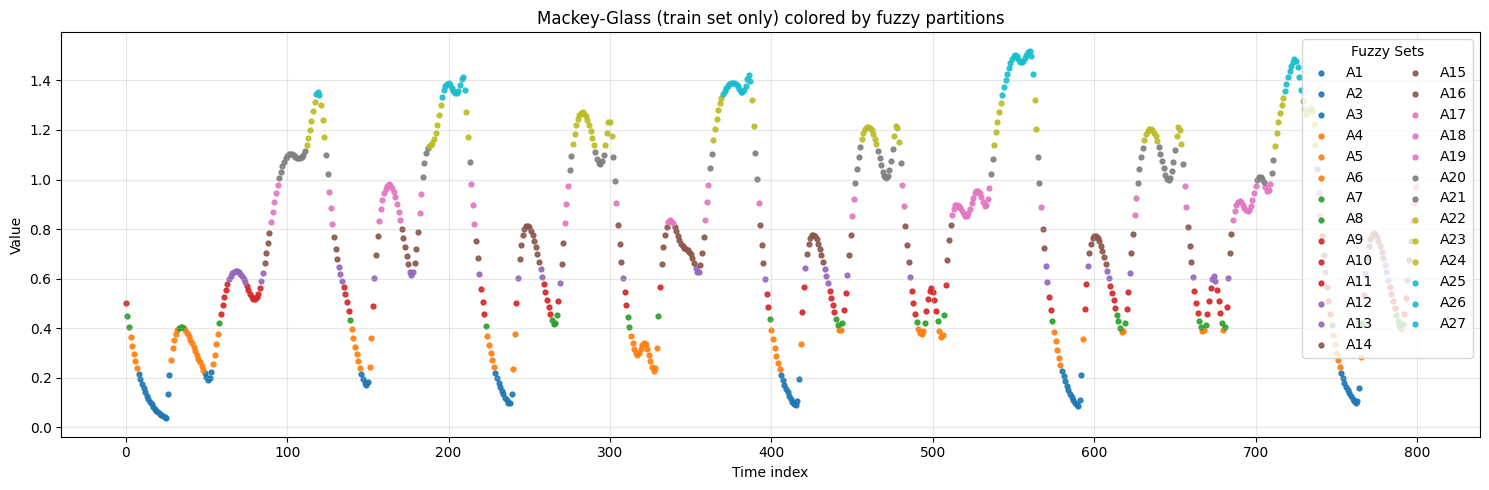

In [593]:
n_clusters = len(fuzzy_sets)
colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

train_values = train_df["value"].values               
train_labels = labels[:len(train_df)]                
train_indices = np.arange(len(train_df))              

plt.figure(figsize=(15, 5))

for lbl in range(n_clusters):
    mask = (train_labels == lbl)
    plt.scatter(
        train_indices[mask],
        train_values[mask],
        color=colors[lbl],
        s=12,
        label=f"A{lbl+1}",
        alpha=0.9
    )

plt.title("Mackey-Glass (train set only) colored by fuzzy partitions")
plt.xlabel("Time index")
plt.ylabel("Value")
plt.legend(title="Fuzzy Sets", loc='upper right', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [594]:


n_clusters = len(centers)
labels_train = labels[:len(train_df)]   


flrg = defaultdict(lambda: defaultdict(int))

for t in range(len(labels_train) - 1):
    current = labels_train[t]
    next_one = labels_train[t+1]
    flrg[current][next_one] += 1

print("FLRG (First-Order, Weighted):")
for lhs in sorted(flrg.keys()):
    rhs_parts = []
    for rhs, count in flrg[lhs].items():
        rhs_parts.append(f"A{rhs+1}({count})")
    print(f"A{lhs+1} → {', '.join(rhs_parts)}")

FLRG (First-Order, Weighted):
A1 → A1(21), A2(2), A3(3)
A2 → A2(9), A1(5), A3(1), A4(1)
A3 → A3(25), A2(5), A4(4), A5(2)
A4 → A4(22), A3(7), A5(4), A6(2), A7(1)
A5 → A4(9), A5(11), A6(2), A8(1), A9(2)
A6 → A5(8), A6(13), A7(8), A9(2), A8(1)
A7 → A6(13), A7(6), A9(7), A8(1), A10(1)
A8 → A7(6), A6(2), A9(1), A10(1), A11(1)
A9 → A8(8), A9(13), A10(6), A13(3), A7(7), A12(1), A11(2)
A10 → A10(15), A11(1), A13(6), A9(14), A14(1)
A11 → A13(3), A10(3), A14(1)
A12 → A14(1), A10(2)
A13 → A13(24), A11(3), A14(12), A10(9), A12(2)
A14 → A14(30), A15(5), A13(14), A16(10)
A15 → A16(3), A14(6), A17(2), A15(2)
A16 → A17(9), A14(8), A16(20), A15(5)
A17 → A17(22), A18(11), A16(7), A19(2), A15(1)
A18 → A19(8), A17(5), A16(2), A20(1), A18(4)
A19 → A19(17), A20(8), A17(4), A18(3)
A20 → A20(19), A21(11), A19(4), A18(2), A17(1)
A21 → A21(24), A22(9), A20(7), A19(2), A23(2)
A22 → A22(6), A23(9), A21(5), A20(2)
A23 → A24(6), A21(4), A23(24), A22(6)
A24 → A24(22), A25(5), A23(5), A22(1)
A25 → A25(12), A24(3), A2

In [595]:
order = 2

flrg_ho = defaultdict(lambda: defaultdict(int))

for t in range(order, len(labels_train)):
    lhs = tuple(labels_train[t-order : t])   
    rhs = labels_train[t]
    flrg_ho[lhs][rhs] += 1  

print(f"FLRG (High-Order Weighted, order={order}):")
print("-" * 50)

for lhs_tuple in sorted(flrg_ho.keys()):
    lhs_str = " → ".join(f"A{i+1}" for i in lhs_tuple)
    
    rhs_parts = []
    for rhs, count in flrg_ho[lhs_tuple].items():
        rhs_parts.append(f"A{rhs+1}({count})")
    
    print(f"{lhs_str}  →  {', '.join(rhs_parts)}")



FLRG (High-Order Weighted, order=2):
--------------------------------------------------
A1 → A1  →  A1(16), A2(2), A3(3)
A1 → A2  →  A3(1), A4(1)
A1 → A3  →  A5(2), A4(1)
A2 → A1  →  A1(5)
A2 → A2  →  A2(4), A1(5)
A2 → A3  →  A4(1)
A2 → A4  →  A6(1)
A3 → A2  →  A2(5)
A3 → A3  →  A3(18), A2(5), A4(2)
A3 → A4  →  A5(1), A4(1), A6(1), A7(1)
A3 → A5  →  A9(2)
A4 → A3  →  A3(7)
A4 → A4  →  A4(12), A3(7), A5(3)
A4 → A5  →  A5(2), A6(1), A8(1)
A4 → A6  →  A9(2)
A4 → A7  →  A10(1)
A5 → A4  →  A4(9)
A5 → A5  →  A6(1), A5(5), A4(5)
A5 → A6  →  A6(1), A7(1)
A5 → A8  →  A10(1)
A5 → A9  →  A11(2)
A6 → A5  →  A4(4), A5(4)
A6 → A6  →  A7(5), A6(5), A5(2), A8(1)
A6 → A7  →  A7(1), A9(7)
A6 → A8  →  A11(1)
A6 → A9  →  A13(2)
A7 → A6  →  A5(5), A6(6), A7(2)
A7 → A7  →  A7(1), A6(4), A8(1)
A7 → A8  →  A9(1)
A7 → A9  →  A9(2), A10(4), A13(1)
A7 → A10  →  A13(1)
A8 → A6  →  A6(1), A5(1)
A8 → A7  →  A6(3), A7(3)
A8 → A9  →  A12(1)
A8 → A10  →  A14(1)
A8 → A11  →  A14(1)
A9 → A7  →  A6(6), A7(1)
A9 → A8  →  

In [596]:
def centroid_of_fuzzy_sets(rhs_dict, centers):
    """
    Centroid of fuzzy sets (مرکز ثقل مجموعه‌های فازی)

    Parameters:
    rhs_dict : dict
        Dictionary of memberships/frequencies for each fuzzy set.
    centers : dict or list
        Centers (centroids) of each fuzzy set.

    Returns:
    float
        Defuzzified value using centroid (weighted average) method.
    """
    import numpy as np

    if not rhs_dict:
        return np.nan

    numerator = 0.0
    denominator = 0.0

    for idx, weight in rhs_dict.items():
        numerator += centers[idx] * weight
        denominator += weight

    return numerator / denominator


def predict_fofts(current_idx, flrg, centers):
    if current_idx not in flrg or not flrg[current_idx]:
        return centers[current_idx]
    return centroid_of_fuzzy_sets(flrg[current_idx], centers)


def predict_hofts(prev_seq, flrg_ho, centers, order):
    key = tuple(prev_seq)
    if key not in flrg_ho or not flrg_ho[key]:
        return centers[prev_seq[-1]]
    return centroid_of_fuzzy_sets(flrg_ho[key], centers)

In [597]:
def evaluate_model_on_data(
    values,          
    start_labels,     
    flrg, flrg_ho, centers, order=2,
    model_type='both'
):
    if len(values) < 2:
        return None, None, None

    actual = values[1:]        
    preds_fofts = []
    preds_hofts = []

    if model_type in ['fofts', 'both']:
        current = start_labels[-1]  
        for _ in range(len(values)-1):
            pred = predict_fofts(current, flrg, centers)
            preds_fofts.append(pred)
            current = which_partition(pred, fuzzy_sets)  

    if model_type in ['hofts', 'both']:
        current_seq = list(start_labels[-order:])   
        for _ in range(len(values)-1):
            pred = predict_hofts(current_seq, flrg_ho, centers, order)
            preds_hofts.append(pred)
            next_p = which_partition(pred, fuzzy_sets)
            current_seq = current_seq[1:] + [next_p]

    results = {}
    if preds_fofts:
        preds_fofts = np.array(preds_fofts)
        mse  = np.mean((actual - preds_fofts)**2)
        rmse = np.sqrt(mse)
        mae  = np.mean(np.abs(actual - preds_fofts))
        results['fofts'] = (mse, rmse, mae)

    if preds_hofts:
        preds_hofts = np.array(preds_hofts)
        mse  = np.mean((actual - preds_hofts)**2)
        rmse = np.sqrt(mse)
        mae  = np.mean(np.abs(actual - preds_hofts))
        results['hofts'] = (mse, rmse, mae)

    return results

In [598]:
results_test = evaluate_model_on_data(
    test_values,
    start_labels = train_labels,           
    flrg=flrg,
    flrg_ho=flrg_ho,
    centers=centers,
    order=2,
    model_type='both'
)

if 'fofts' in results_test:
    mse_f, rmse_f, mae_f = results_test['fofts']
    print("FOFTS (closed-loop):")
    print(f" MSE = {mse_f:.6f}")
    print(f" RMSE = {rmse_f:.4f}")
    print(f" MAE = {mae_f:.4f}\n")

if 'hofts' in results_test:
    mse_h, rmse_h, mae_h = results_test['hofts']
    print("HOFTS(closed-loop):")
    print(f" MSE = {mse_h:.6f}")
    print(f" RMSE = {rmse_h:.4f}")
    print(f" MAE = {mae_h:.4f}\n")

# مقایسه ساده
if 'fofts' in results_test and 'hofts' in results_test:
    print("Best algorithm")
    print(f"  MSE   →  FOFTS " if mse_f < mse_h else "  MSE   →  HOFTS ")
    print(f"  RMSE  →  FOFTS " if rmse_f < rmse_h else "  RMSE  →  HOFTS ")
    print(f"  MAE   →  FOFTS " if mae_f < mae_h else "  MAE   →  HOFTS ")

FOFTS (closed-loop):
 MSE = 0.159836
 RMSE = 0.3998
 MAE = 0.3310

HOFTS(closed-loop):
 MSE = 0.159538
 RMSE = 0.3994
 MAE = 0.3306

Best algorithm
  MSE   →  HOFTS 
  RMSE  →  HOFTS 
  MAE   →  HOFTS 


In [599]:


from sklearn.metrics import r2_score

def get_predictions(model_type='hofts', order=2):
    
    test_labels = labels[len(train_df):]

    
    if model_type == 'fofts':
        preds = []

        for t in range(len(test_values) - 1):
            current_label = test_labels[t]          
            pred = predict_fofts(current_label, flrg, centers)
            preds.append(pred)

        return np.array(preds)


    else:
        preds = []

       
        for t in range(order, len(test_values)):
            seq = test_labels[t-order:t]      
            pred = predict_hofts(seq, flrg_ho, centers, order)
            preds.append(pred)

        return np.array(preds)



pred_fofts = get_predictions('fofts')
pred_hofts = get_predictions('hofts')

actual_test_fofts = test_values[1:]
actual_test_hofts = test_values[order:]

def compute_metrics(y_true, y_pred, name="Model"):
    mse  = np.mean((y_true - y_pred)**2)
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)

    accuracy = 100 - mape
    
    print(f"\n{name}")
    print(f"   MSE  = {mse:8.6f}")
    print(f"   RMSE = {rmse:8.4f}")
    print(f"   MAE  = {mae:8.4f}")
    print(f"   MAPE = {mape:8.3f} %")
    print(f"   R²   = {r2:8.4f}")
    print(f"   Accuracy = {accuracy:8.3f} %")

    return mse, rmse, mae, mape, r2, accuracy



print("═"*60)
print("          TEST SET ACCURACY METRICS")
print("═"*60)

metrics_fofts = compute_metrics(actual_test_fofts, pred_fofts, "FOFTS (one-step)")
metrics_hofts = compute_metrics(actual_test_hofts, pred_hofts, "HOFTS (one-step)")

best = "HOFTS" if metrics_hofts[0] < metrics_fofts[0] else "FOFTS"
print("\n" + "─"*60)
print(f"🏆 Best model on Test set → {best}")
print("─"*60)

════════════════════════════════════════════════════════════
          TEST SET ACCURACY METRICS
════════════════════════════════════════════════════════════

FOFTS (one-step)
   MSE  = 0.003972
   RMSE =   0.0630
   MAE  =   0.0470
   MAPE =    6.769 %
   R²   =   0.9734
   Accuracy =   93.231 %

HOFTS (one-step)
   MSE  = 0.002990
   RMSE =   0.0547
   MAE  =   0.0385
   MAPE =    5.078 %
   R²   =   0.9800
   Accuracy =   94.922 %

────────────────────────────────────────────────────────────
🏆 Best model on Test set → HOFTS
────────────────────────────────────────────────────────────
